### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

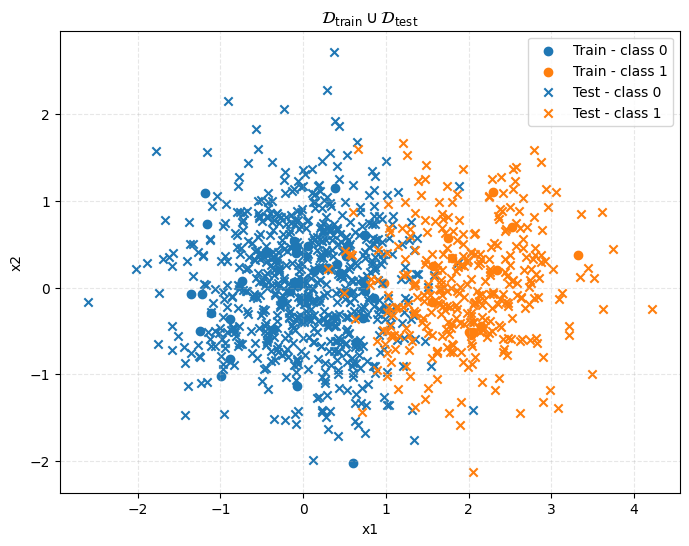

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

def createDataPoints(N,eps,p):
    X = np.zeros((N, 2))
    Y = np.zeros(N)
    for i in range(N):
        U = np.random.rand()

        # y processing 
        y = 0
        if U < p :
            y = 1
        Y[i] = y

        # X processing
        if not(y) :#y=1
            X[i] = np.random.multivariate_normal([0,0],[[0.5,0],[0,0.5]])
        else :
            X[i] = np.random.multivariate_normal([eps,0],[[0.4,0],[0,0.4]])

    return X,Y

X_train, y_train = createDataPoints(50, 2, 0.3)
X_test, y_test =  createDataPoints(10**3, 2, 0.3)

# Plots
plt.figure(figsize=(8, 6))

# Train points
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c="tab:blue", marker="o", label="Train - class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c="tab:orange", marker="o", label="Train - class 1")

# Test points
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            c="tab:blue", marker="x", label="Test - class 0")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            c="tab:orange", marker="x", label="Test - class 1")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(r"$\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

The optimal Bayes classifier is defined as follows:
$$
    f(x) = \mathbb{1}\left(\frac{P(Y = 1 | \mathbf{x})}{P(Y = 0 | \mathbf{x})} > 1\right) \tag{1}
$$

By Bayes formula, we have:

$$
    P(Y = k | \mathbf{x}) = \frac{P(\mathbf{x} | Y = k) P(Y = k)}{P(\mathbf{x})}
    = \frac{p_{\mathcal{N}(\boldsymbol{\mu_k}, \boldsymbol{\Sigma_k})}(\mathbf{x}) p}{P(\mathbf{x})}
    \text{ for } k = 0, 1 \tag{2}
$$ 

We'll compute what's inside the  function of $(1)$.
By taking the $\log$ of $(1)$, we obtain:

$$
    \log \left(p_{\mathcal{N}(\boldsymbol{\mu_1}, \boldsymbol{\Sigma_1})}(\mathbf{x}) \right)
    - \log \left(p_{\mathcal{N}(\boldsymbol{\mu_0}, \boldsymbol{\Sigma_0})}(\mathbf{x}) \right)
    + \log \left(\frac{p}{1 - p}\right) > 0
$$

and then with $(2)$

$$
    \frac{1}{2} \log \left(\frac{\det \Sigma_0}{\det \Sigma_1} \right) - \frac{1}{2} (\mathbf{x} - \mu_1)^\top \Sigma_1 ^ {-1} (\mathbf{x} - \mu_1)
    + \frac{1}{2} (\mathbf{x} - \mu_0)^\top \Sigma_0 ^ {-1} (\mathbf{x} - \mu_0) + \log \left(\frac{p}{1 - p}\right) > 0
$$

Finally, the optimal Bayes classifier is:
$$
\mathbb{1}\left(\frac{1}{2} \log \left(\frac{\det \Sigma_0}{\det \Sigma_1} \right) - \frac{1}{2} (\mathbf{x} - \mu_1)^\top \Sigma_1 ^ {-1} (\mathbf{x} - \mu_1)
    + \frac{1}{2} (\mathbf{x} - \mu_0)^\top \Sigma_0 ^ {-1} (\mathbf{x} - \mu_0) + \log \left(\frac{p}{1 - p}\right) > 0 \right)
$$

The boundary is when it's equal to zero.

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

Error for epsilon = 2 Bayes :  0.066


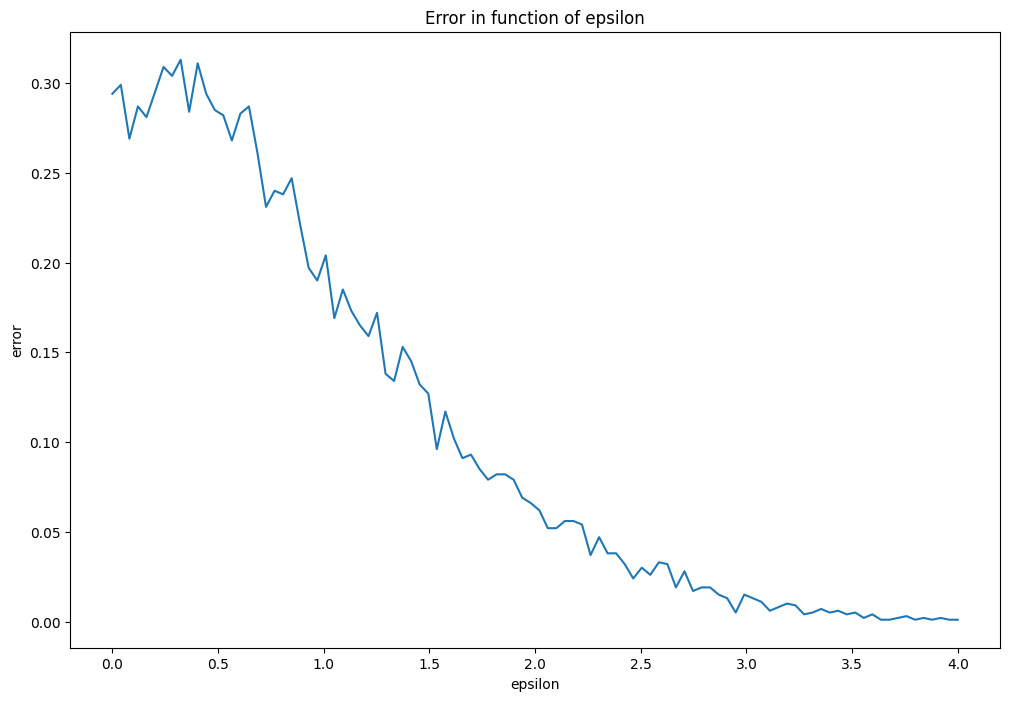

In [2]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import validate_data, check_is_fitted
from sklearn.utils.multiclass import unique_labels

class BayesClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, mu0,  cov0,mu1, cov1, p):
        self.mu0 = mu0
        self.cov0 = cov0
        self.mu1 = mu1
        self.cov1 = cov1
        self.p = p

    def fit(self, X, y):
        X, y = validate_data(self, X, y)
        self.classes_ = unique_labels(y)
    
        self.coefZo = 1 / (2*np.pi*np.sqrt(np.linalg.det(self.cov0)))
        self.coefZ1 = 1 / (2*np.pi*np.sqrt(np.linalg.det(self.cov1)))
        self.cov0Inv = np.linalg.inv(self.cov0)
        self.cov1Inv = np.linalg.inv(self.cov1)
        return self

    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, reset=False)
        diff0 = X - self.mu0
        diff1 = X - self.mu1
        quad0 = np.einsum("ij,ij->i", diff0 @ self.cov0Inv, diff0)
        quad1 = np.einsum("ij,ij->i", diff1 @ self.cov1Inv, diff1)
        log0 = np.log(1 - self.p) + np.log(self.coefZo) - 0.5 * quad0
        log1 = np.log(self.p) + np.log(self.coefZ1) - 0.5 * quad1
        return np.where(log0 > log1, 0, 1)
    
clf= BayesClassifier(
        mu0=np.array([0, 0]),
        cov0=np.array([[0.5, 0], [0, 0.5]]),
        mu1=np.array([2, 0]),
        cov1=np.array([[0.4, 0], [0, 0.4]]),
        p=0.3   
)

clf.fit(X_test, y_test)
print("Error for epsilon = 2 Bayes : ", np.mean(clf.predict(X_test) != y_test))


#Error in function of epsilon
epsilon = np.linspace(0, 4, 100)
error_rates = []
for eps in epsilon:
    # Create a new BayesClassifier with the current epsilon
    X_test, y_test =  createDataPoints(10**3, eps, 0.3)
    clf = BayesClassifier(
        mu0=np.array([0, 0]),
        cov0=np.array([[0.5, 0], [0, 0.5]]),
        mu1=np.array([eps, 0]),
        cov1=np.array([[0.4, 0], [0, 0.4]]),
        p=0.3   
    )
    
    clf.fit(X_test, y_test)
    y_pred = clf.predict(X_test)
    error_rate = np.mean(y_pred != y_test)
    error_rates.append(error_rate)
    
# Plotting the error rates
plt.figure(figsize=(12,8))
plt.plot(epsilon,error_rates)
plt.xlabel("epsilon")
plt.ylabel("error")
plt.title("Error in function of epsilon")
plt.show()




As epsilon increases, it separates the two classes along the x-axis. This means there will be less overlap, so we can more easily deduce which class a point comes from. This is why the error curve decreases.

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

The datasets are generated by Gaussian distributions  with different covariance matrices. Consequently, the QDA classifiers is the most adequate because it relies on these assumptions.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Error rate for LDA with epsilon = 2  with train size  50 :  0.058
Error rate for QDA with epsilon = 2  with train size  50 :  0.057
Error rate for Logistic Regression with epsilon = 2  with train size  50 :  0.062


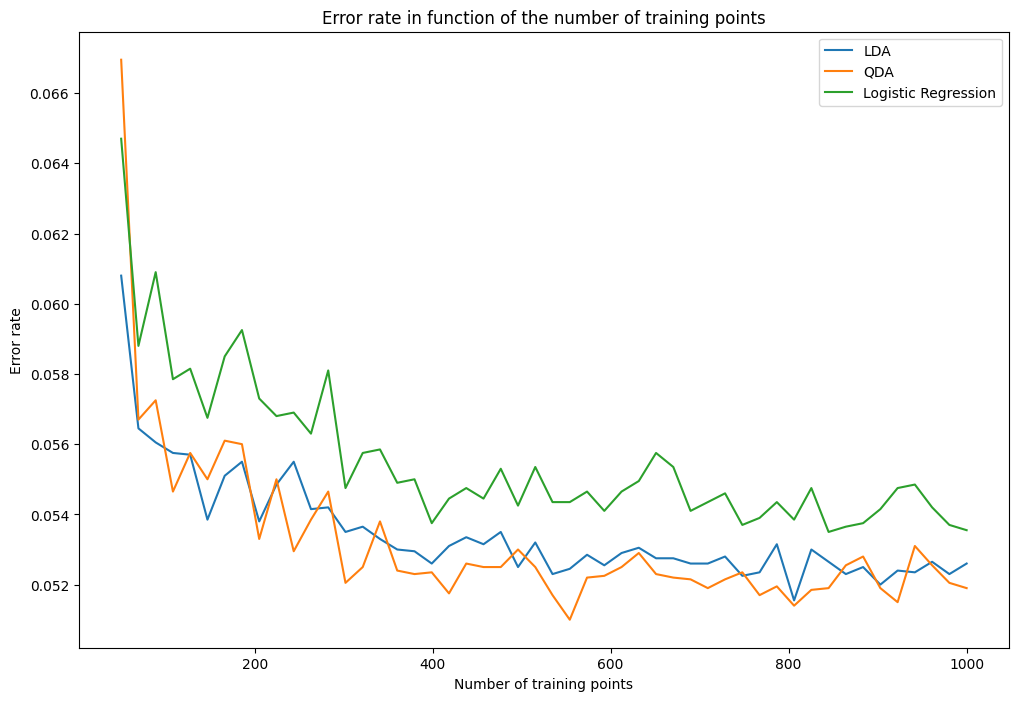

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression


eps=2
p=0.3
X_train, y_train = createDataPoints(50,eps,p)
X_test, y_test = createDataPoints(10**3, eps, p) 
clf=LinearDiscriminantAnalysis()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
error_rate = np.mean(y_pred != y_test)
print("Error rate for LDA with epsilon = 2  with train size ", X_train.shape[0], ": ", error_rate)
clf=QuadraticDiscriminantAnalysis()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
error_rate = np.mean(y_pred != y_test)
print("Error rate for QDA with epsilon = 2  with train size ", X_train.shape[0], ": ", error_rate)
clf=LogisticRegression()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
error_rate = np.mean(y_pred != y_test)
print("Error rate for Logistic Regression with epsilon = 2  with train size ", X_train.shape[0], ": ", error_rate) 

#error in function of the number of training points
len_train = np.linspace(50, 1000, 50)
error_rates_lda = []
error_rates_qda = []
error_rates_logistic = []
for n in len_train:
    # Average over multiple runs to smooth the curve
    err_lda, err_qda, err_log= 0, 0, 0
    n_runs = 20
    for _ in range(n_runs):
        X_train, y_train = createDataPoints(int(n), eps, p)
        
        clf=LinearDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_lda += np.mean(clf.predict(X_test) != y_test)
        
        clf=QuadraticDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_qda += np.mean(clf.predict(X_test) != y_test)
        
        clf=LogisticRegression()
        clf.fit(X_train,y_train)
        err_log += np.mean(clf.predict(X_test) != y_test)
        
    error_rates_lda.append(err_lda / n_runs)
    error_rates_qda.append(err_qda / n_runs)
    error_rates_logistic.append(err_log / n_runs)


plt.figure(figsize=(12,8))
plt.plot(len_train,error_rates_lda, label="LDA", color="tab:blue")
plt.plot(len_train,error_rates_qda, label="QDA", color="tab:orange")
plt.plot(len_train,error_rates_logistic, label="Logistic Regression", color="tab:green")
plt.xlabel("Number of training points")
plt.ylabel("Error rate")
plt.title("Error rate in function of the number of training points")
plt.legend()
plt.show()
    

How do their errors compare to the value obtained in (c)?

As we can see, the errors obtained for LDA, QDA, and logistic regression ,with  $\mathcal{D}_{\text{train}}$ and $\mathcal{D}_{\text{test}}$  are higher than the one obtained with our Bayes classifier, but not by much (about +0.025).

Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change?

From the plot, we observe that when the training set is small, all three classifiers have relatively high error rates. As the training set size increases, QDA tends to perform better than LDA. Logistic regression is more variable, but in most cases it remains close to QDA’s error rate. This ranking is consistent with what we would expect from the theoretical assumptions. Empirically, even though the gap between each classifier and the Bayes classifier decreases at first, the curves eventually reach a plateau. The Bayes classifier remains the best.

Theoretically, what is happening?

First, this illustrates the bias–variance trade-off. Training a classifier means estimating parameters from data. Models with more parameters typically have higher variance and therefore require more data to generalize well. Here, even though QDA matches the data-generating assumptions, it has more parameters to estimate than LDA (two covariance matrices instead of one). As a result, with very little data, LDA can sometimes outperform QDA, but as the number of training examples increases, QDA tends to become better.

Second, the plot highlights the difference between generative and discriminative methods. In our setting, the two classes are not heavily overlapping, so a linear decision boundary can already work well, even without explicitly estimating the class-conditional distributions. Moreover, logistic regression has relatively few parameters to estimate, which contributes to its stability.

In conclusion, increasing the size of the training set reduces the gap between the learned classifiers and the optimal (Bayes) classifier. However, some models have an inherent bias and may never reach the Bayes performance, even with a very large amount of data. Finally, both generative and discriminative approaches can approximate the Bayes classifier well, but models with more parameters may need more data before achieving their best performance.


**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

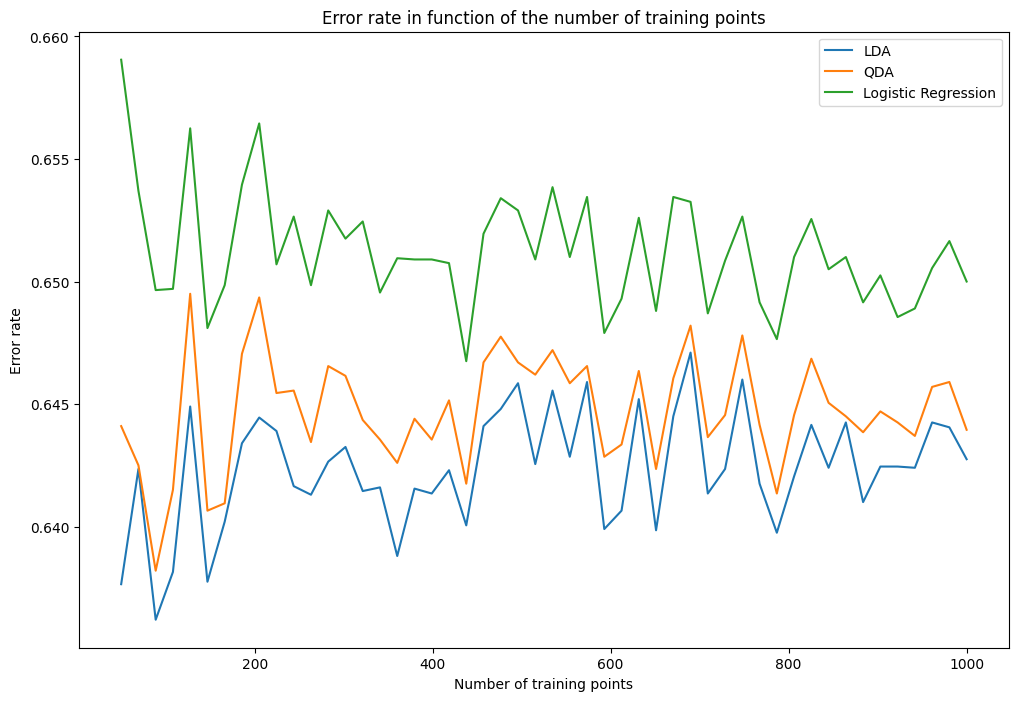

Error for epsilon = 0.5  Bayes:  0.607


In [4]:

X_test, y_test =  createDataPoints(10**3, 0.5, 0.7)

#error in function of the number of training points
len_train = np.linspace(50, 1000, 50)
error_rates_lda = []
error_rates_qda = []
error_rates_logistic = []
for n in len_train:
    # Average over multiple runs to smooth the curve
    err_lda, err_qda, err_log= 0, 0, 0
    n_runs = 20
    for _ in range(n_runs):
        X_train, y_train = createDataPoints(int(n), eps, p)
        
        clf=LinearDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_lda += np.mean(clf.predict(X_test) != y_test)
        
        clf=QuadraticDiscriminantAnalysis()
        clf.fit(X_train,y_train)
        err_qda += np.mean(clf.predict(X_test) != y_test)
        
        clf=LogisticRegression()
        clf.fit(X_train,y_train)
        err_log += np.mean(clf.predict(X_test) != y_test)
        
    error_rates_lda.append(err_lda / n_runs)
    error_rates_qda.append(err_qda / n_runs)
    error_rates_logistic.append(err_log / n_runs)


plt.figure(figsize=(12,8))
plt.plot(len_train,error_rates_lda, label="LDA", color="tab:blue")
plt.plot(len_train,error_rates_qda, label="QDA", color="tab:orange")
plt.plot(len_train,error_rates_logistic, label="Logistic Regression", color="tab:green")
plt.xlabel("Number of training points")
plt.ylabel("Error rate")
plt.title("Error rate in function of the number of training points")
plt.legend()
plt.show()

clf = BayesClassifier(
        mu0=np.array([0, 0]),
        cov0=np.array([[0.5, 0], [0, 0.5]]),
        mu1=np.array([0.5, 0]),
        cov1=np.array([[0.4, 0], [0, 0.4]]),
        p=0.3   
    )
clf.fit(X_test, y_test)
print("Error for epsilon = 0.5  Bayes: ", np.mean(clf.predict(X_test) != y_test))


The plot highlights what was discussed in the previous question. Here, since $\varepsilon=0.5$, the two class-conditional distributions overlap more because one of them is translated less along the x-axis. As a result, the setting becomes closer to LDA’s assumptions, and its performance improve relatively to the previous case.

On the other hand, the linear decision boundary of the logistic regression model, trained on the unchanged training dataset, becomes more biased in this new configuration, which explains why its error increases slightly. QDA can also suffer in this regime.

Finally, changing p makes the effect of the change in $\varepsilon$ more visible, since the class that is most affected by this change now has more examples (70%), so the classifiers are evaluated more heavily on this case.

In conclusion, these two modifications explain why the ranking of the curves has changed.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

### Imports

In [5]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from skrub import tabular_pipeline
from sklearn.linear_model import LogisticRegression

Run this command to submit a prediction directly in the terminal (must have already installed kaggle and generated a Kaggle Token) --> or submit on the Kaggle website
```bash
kaggle competitions submit -c titanic -f ma_prediction.csv -m "Test avec Random Forest"
```

### Upload data

In [6]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("Size of the train dataset:", df_train.shape)
print("Size of the test dataset:", df_test.shape)

df_train.head(10)

Size of the train dataset: (891, 12)
Size of the test dataset: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
y_train = df_train["Survived"]
X_train = df_train.drop(columns=["Survived", "Name", "PassengerId"])
X_test = df_test.drop(columns=["Name", "PassengerId"])

print("Number of NaN values for each row (max 891):")
891 - X_train.count()

Number of NaN values for each row (max 891):


Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

### Exploring the data

In [8]:
# Passenger with cabin number
cab = df_train[df_train["Cabin"].notna()].copy()

print(f"With cabin: {len(cab)} / {len(df_train)} ({100*len(cab)/len(df_train):.1f}%)")

def compare_rates(df_all, df_sub, col, bins=None):
    if bins is None:
        s_all = df_all[col]
        s_sub = df_sub[col]
    else:
        s_all = pd.cut(df_all[col], bins=bins, right=False, include_lowest=True)
        s_sub = pd.cut(df_sub[col], bins=bins, right=False, include_lowest=True)

    all_pct = 100 * s_all.value_counts(dropna=False, normalize=True)
    sub_pct = 100 * s_sub.value_counts(dropna=False, normalize=True)

    out = pd.concat(
        [all_pct.rename("all_data_%"), sub_pct.rename("with_cabin_%")],
        axis=1
    ).fillna(0)

    out["delta_pp"] = out["with_cabin_%"] - out["all_data_%"]
    return out.round(2)

# Discrete variables
for col in ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]:
    print("\n" + "="*50)
    print(f"{col} (all data vs with cabin)")
    print(compare_rates(df_train, cab, col).sort_values("delta_pp", ascending=False))

print()
print("-" * 100)
print()

# Passenger without cabin number
cab = df_train[df_train["Cabin"].isna()].copy()

print(f"Without cabin: {len(cab)} / {len(df_train)} ({100*len(cab)/len(df_train):.1f}%)")

def compare_rates(df_all, df_sub, col, bins=None):
    if bins is None:
        s_all = df_all[col]
        s_sub = df_sub[col]
    else:
        s_all = pd.cut(df_all[col], bins=bins, right=False, include_lowest=True)
        s_sub = pd.cut(df_sub[col], bins=bins, right=False, include_lowest=True)

    all_pct = 100 * s_all.value_counts(dropna=False, normalize=True)
    sub_pct = 100 * s_sub.value_counts(dropna=False, normalize=True)

    out = pd.concat(
        [all_pct.rename("all_data_%"), sub_pct.rename("without_cabin_%")],
        axis=1
    ).fillna(0)

    out["delta_pp"] = out["without_cabin_%"] - out["all_data_%"]
    return out.round(2)

# Discrete variables
for col in ["Pclass", "Sex", "SibSp", "Parch", "Embarked"]:
    print("\n" + "="*50)
    print(f"{col} (all data vs without cabin)")
    print(compare_rates(df_train, cab, col).sort_values("delta_pp", ascending=False))

With cabin: 204 / 891 (22.9%)

Pclass (all data vs with cabin)
        all_data_%  with_cabin_%  delta_pp
Pclass                                    
1            24.24         86.27     62.03
2            20.65          7.84    -12.81
3            55.11          5.88    -49.22

Sex (all data vs with cabin)
        all_data_%  with_cabin_%  delta_pp
Sex                                       
female       35.24         47.55     12.31
male         64.76         52.45    -12.31

SibSp (all data vs with cabin)
       all_data_%  with_cabin_%  delta_pp
SibSp                                    
1           23.46         33.82     10.37
2            3.14          2.94     -0.20
3            1.80          1.47     -0.33
5            0.56          0.00     -0.56
8            0.79          0.00     -0.79
4            2.02          0.00     -2.02
0           68.24         61.76     -6.47

Parch (all data vs with cabin)
       all_data_%  with_cabin_%  delta_pp
Parch                               

#### Observations:

A lot of missing values for cabin

TODO: exploit the results above in in order to fill the missing cabin values or create a new_row for the persons whithout a cabin number

In [9]:
def export_result_to_csv(y_pred, filename="submission.csv"):
    submission = pd.DataFrame({
        "PassengerId": df_test["PassengerId"],
        "Survived": y_pred
    })
    submission.to_csv(filename, index=False)

### Simple model `Skrub`

In [10]:
model = tabular_pipeline("classifier") # use random --> not reproducible results (not have random_state parameter)

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# Export to CSV
# export_result_to_csv(y_pred_test, "skrub_auto_preprocessing.csv")

too general and can't adapt to the specificity of the problem
best score:  0.78947

### With `ColumnTransformer` and `LogisticRegression`

In [12]:
# Apply different preprocessing per column type before classification.
numeric_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # replace Nan Values with the median
        ("scaler", StandardScaler()), # standarize data by centering and reducing
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), # replace Nan values by the most frequent feature
        ("onehot", OneHotEncoder(handle_unknown="ignore")), # OneHotEncoding of the categorical features
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop", # remove all the non specified cols in numeric_features or categorical_features --> 0 here
)

# Logistic Regression
logreg = LogisticRegression(
    random_state=1,
)

model = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("classifier", logreg)
    ]
)

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# Export to CSV
# export_result_to_csv(y_pred_test, filename="Log_reg_naive_preprocessor.csv")

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?